In [2]:
import pandas as pd
import bambi as bmb
import arviz as az
import arviz_plots as azp

df = pd.read_csv('/Users/fiodarzianiutsich/Desktop/projekt/data_cleaning/red_spruce_2022.csv')
df.columns

Index(['inventory_year', 'survey_unit', 'county', 'plot_number', 'tree_number',
       'diameter', 'height', 'SPCD', 'log_height', 'log_diameter'],
      dtype='str')

Here we define our hierarchical model. We account for both the macroclimate (the county level) and the microclimate (the specific plot level) to capture the natural variation in the forest

In [3]:
model_formula = "log_height ~ log_diameter + (1 | county) + (1 | county:plot_number)"

model = bmb.Model(model_formula, df)

We increase target_accept to 0.99 because of our specific data structure (e.g., plots with very few trees). We sacrifice some computation time to force the algorithm to take smaller steps, but we gain mathematical accuracy and prevent sampling errors (divergences)


In [4]:
results = model.fit(draws=2000, tune=2000, target_accept=0.99)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [sigma, Intercept, log_diameter, 1|county_sigma, 1|county_offset, 1|county:plot_number_sigma, 1|county:plot_number_offset]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 21 seconds.


In [5]:
az.summary(results, var_names=["Intercept", "log_diameter", "sigma", "1|county_sigma", "1|county:plot_number_sigma"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,0.171,0.052,0.077,0.273,0.001,0.001,5850.0,5787.0,1.0
log_diameter,0.786,0.017,0.755,0.817,0.000,0.000,8417.0,6148.0,1.0
sigma,0.165,0.007,0.152,0.177,0.000,0.000,8996.0,5498.0,1.0
1|county_sigma,0.038,0.029,0.000,0.088,0.001,0.001,1078.0,2085.0,1.0
1|county:plot_number_sigma,0.141,0.019,0.107,0.176,0.000,0.000,2397.0,4301.0,1.0


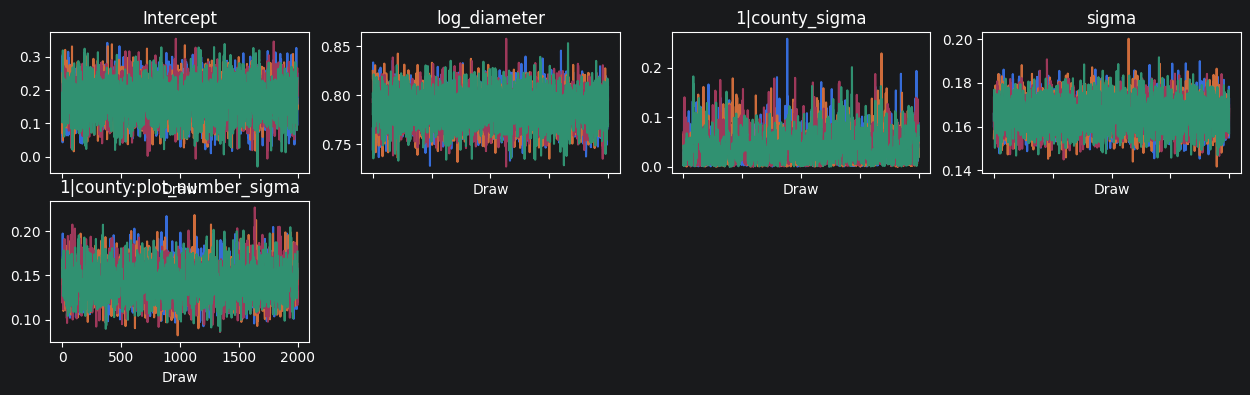

In [7]:
azp.plot_trace(results, var_names=["Intercept", "log_diameter", "1|county_sigma", "sigma", "1|county:plot_number_sigma"])

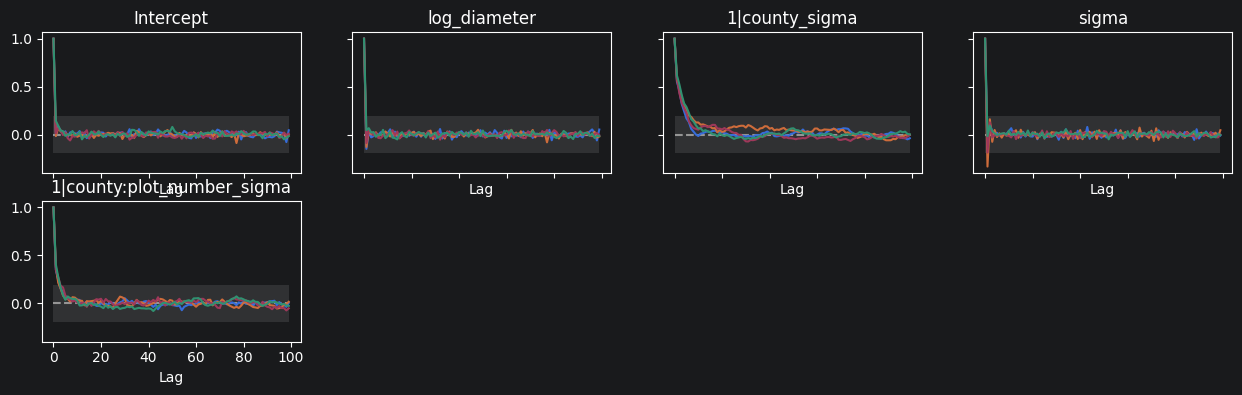

In [8]:
azp.plot_autocorr(results, var_names=["Intercept", "log_diameter","1|county_sigma", "sigma", "1|county:plot_number_sigma"])

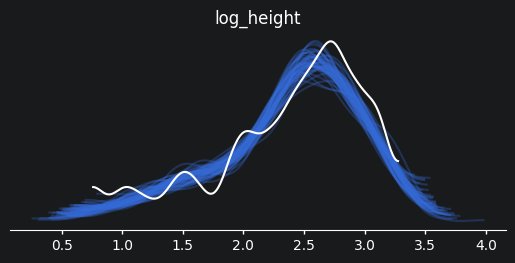

In [9]:
model.predict(results, kind="response")
azp.plot_ppc_dist(results)

array([<Axes: title={'center': '94.0% HDI'}>], dtype=object)

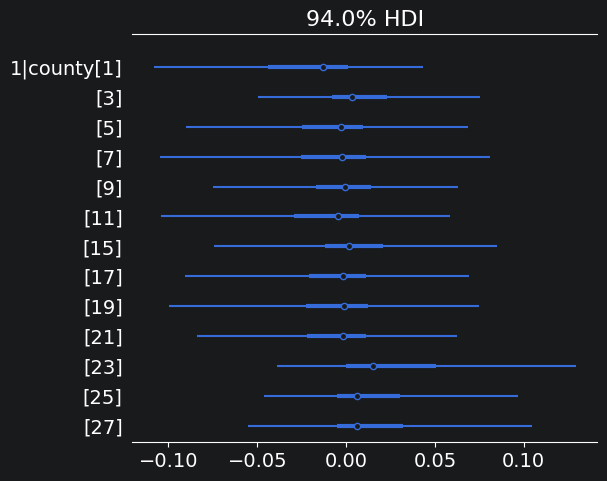

In [10]:
az.plot_forest(results, var_names=["1|county"], combined = True)